# Notebook 05: Location-Scale Models for Quantile Regression

## Learning Objectives

By the end of this notebook, you will be able to:

1. Understand location-scale decomposition of quantiles
2. Model heteroskedasticity explicitly through scale function
3. Use location-scale models to prevent quantile crossing
4. Test for heteroskedasticity in QR context
5. Compare location-scale QR with standard QR
6. Interpret location and scale coefficients separately

## Duration
150 minutes

## Prerequisites
- Notebooks 01-02 (Quantile Regression Fundamentals, Multiple Quantiles)
- Heteroskedasticity concepts

## Dataset
Financial returns panel: ~200 firms over ~60 months, with stock returns, size, book-to-market, momentum, and volatility.

In [1]:
# Standard libraries
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# Statistical libraries
from scipy import stats

from panelbox.core.panel_data import PanelData

# PanelBox imports
from panelbox.models.quantile import LocationScale, PooledQuantile

# Visualization configuration
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

# Reproducibility
np.random.seed(42)

# Define paths (relative to notebooks/)
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
PLOTS_DIR = OUTPUT_DIR / "plots"
RESULTS_DIR = OUTPUT_DIR / "results"

# Create output directories
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete!")
print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Setup complete!
Data directory: ../data
Output directory: ../outputs


---

## 1. Introduction & Motivation

### Research Question

> *"In financial returns, does volatility (risk) depend on firm characteristics? Can we model both mean returns AND volatility jointly?"*

### Two Approaches to Quantile Modeling

| Approach | Formulation | Properties |
|----------|------------|------------|
| **Standard QR** | $Q_\tau(Y \mid X) = X'\beta(\tau)$ | Separate $\beta(\tau)$ for each $\tau$; flexible but may cross |
| **Location-Scale** | $Q_\tau(Y \mid X) = \mu(X) + \sigma(X) \cdot F^{-1}(\tau)$ | Joint estimation; monotonic by construction |

### Key Insight

```
STANDARD QR: Estimates Q_\u03c4(Y|X) = X'\u03b2(\u03c4) directly
  \u2192 Separate estimation for each \u03c4
  \u2192 May violate monotonicity (crossing)
  \u2192 Doesn't explicitly model heteroskedasticity

LOCATION-SCALE: Q_\u03c4(Y|X) = \u03bc(X) + \u03c3(X) \u00b7 F\u207b\u00b9(\u03c4)
  \u2192 \u03bc(X) = location function (central tendency)
  \u2192 \u03c3(X) = scale function (dispersion/volatility)
  \u2192 Monotonicity guaranteed by construction
  \u2192 Explicit heteroskedasticity model
```

---

## 2. Theoretical Concepts

### 2.1 Location-Scale Model Formulation

The location-scale model assumes that the conditional distribution of $Y$ given $X$ can be written as:

$$Y_i = \mu(X_i) + \sigma(X_i) \cdot \varepsilon_i$$

where:
- $\mu(X_i) = X_i'\alpha$ is the **location function** (conditional mean)
- $\sigma(X_i) = \exp(X_i'\gamma / 2)$ is the **scale function** (conditional standard deviation)
- $\varepsilon_i \sim F$ is a standardized error with known reference distribution

The conditional quantile is then:

$$Q_\tau(Y \mid X) = X'\alpha + \exp(X'\gamma / 2) \cdot F^{-1}(\tau)$$

### 2.2 Common Reference Distributions

| Distribution | $F^{-1}(\tau)$ | Tail behavior | Use case |
|-------------|----------------|---------------|----------|
| **Normal** | $\Phi^{-1}(\tau)$ | Light tails | Default; financial returns (approx) |
| **Logistic** | $\log(\tau / (1-\tau))$ | Heavier tails | More robust to outliers |
| **Student-t** | $t_\nu^{-1}(\tau)$ | Fat tails ($\nu$ controls) | Financial data with fat tails |
| **Laplace** | Laplace quantile | Moderate tails | Robust estimation |

### 2.3 Identification and Estimation

The MSS (2019) approach estimates the model in **two steps**:

1. **Step 1 (Location)**: Estimate $\hat{\alpha}$ via OLS regression of $Y$ on $X$
2. **Step 2 (Scale)**: Estimate $\hat{\gamma}$ from regression of $\log|\hat{\varepsilon}_i|$ on $X$, with appropriate adjustment for $E[\log|\varepsilon|]$ under distribution $F$

The effective quantile coefficient is then:

$$\hat{\beta}(\tau) = \hat{\alpha} + \exp(\hat{\gamma}/2) \cdot F^{-1}(\tau)$$

### 2.4 Key Advantages

- **Monotonicity**: Since $F^{-1}(\tau)$ is strictly increasing in $\tau$, and $\sigma(X) > 0$, the quantile function is automatically monotone $\Rightarrow$ **no crossing**
- **Interpretability**: Clean separation of location ($\alpha$) and scale ($\gamma$) effects
- **Efficiency**: Only $2k$ parameters to estimate (vs $k$ per quantile in standard QR)
- **Density prediction**: The parametric structure allows full density estimation

In [2]:
# Load financial returns data
data = pd.read_csv(DATA_DIR / "financial_returns.csv")

# Panel structure
print(f"Dataset shape: {data.shape}")
print(f"Variables: {data.columns.tolist()}")
print(f"Firms: {data['firm_id'].nunique()}")
print(f"Time periods: {data['month'].nunique()}")
print(f"Observations: {len(data)}")

print("\nDescriptive Statistics:")
display(data[["returns", "size", "book_to_market", "momentum", "volatility"]].describe())

Dataset shape: (12000, 8)
Variables: ['firm_id', 'month', 'returns', 'size', 'book_to_market', 'momentum', 'volatility', 'sector']
Firms: 200
Time periods: 60
Observations: 12000

Descriptive Statistics:


,returns,size,book_to_market,momentum,volatility
count,12000.0000,12000.0000,12000.0000,12000.0000,12000.0000
mean,0.2425,8.0843,0.7168,0.0978,0.6530
std,1.2938,1.9931,0.3917,0.3025,0.4490
min,-7.0617,2.9930,-0.0578,-1.0343,0.0045
25%,-0.5095,6.7314,0.4213,-0.1050,0.3261
50%,0.2879,7.9999,0.6880,0.0985,0.5589
75%,1.0292,9.2653,0.9828,0.3017,0.8745
max,11.5569,14.6586,1.9777,1.2427,5.9372


In [3]:
# Create PanelData object
panel = PanelData(data, entity_col="firm_id", time_col="month")
print(panel.summary())

# Formula for financial returns model
formula = "returns ~ size + book_to_market + momentum"

PANEL DATA SUMMARY
Entity identifier: firm_id
Time identifier:   month
------------------------------------------------------------
Number of entities:     200
Number of time periods: 60
Total observations:     12,000
------------------------------------------------------------
Balanced:               Yes
Periods per entity:     60
------------------------------------------------------------
Time period range:      1 to 60


---

## 3. Implementation

### 3.1 Standard QR (Baseline)

First, we estimate standard pooled quantile regression across a grid of quantiles. This gives us a benchmark to compare with the location-scale approach.

In [4]:
# Standard Pooled QR across quantile grid
tau_grid = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

# Prepare arrays for PooledQuantile
y = data["returns"].values
X = np.column_stack(
    [
        np.ones(len(data)),
        data["size"].values,
        data["book_to_market"].values,
        data["momentum"].values,
    ]
)
entity_id = data["firm_id"].values
var_names = ["const", "size", "book_to_market", "momentum"]

print("Estimating Standard Pooled QR...")
print("=" * 60)

qr_results = {}
for tau in tau_grid:
    model = PooledQuantile(y, X, entity_id=entity_id, quantiles=tau)
    qr_results[tau] = model.fit(se_type="cluster")

# Display results
print(f"\n{'Variable':<18}", end="")
for tau in tau_grid:
    print(f"{'t=' + f'{tau:.1f}':>8}", end="")
print()
print("-" * (18 + 8 * len(tau_grid)))

for i, var in enumerate(var_names):
    print(f"{var:<18}", end="")
    for tau in tau_grid:
        coef = (
            qr_results[tau].params[i, 0]
            if qr_results[tau].params.ndim > 1
            else qr_results[tau].params[i]
        )
        print(f"{coef:8.4f}", end="")
    print()

print("\nStandard QR estimation complete.")

Estimating Standard Pooled QR...



Variable             t=0.1   t=0.2   t=0.3   t=0.4   t=0.5   t=0.6   t=0.7   t=0.8   t=0.9
------------------------------------------------------------------------------------------
const              -4.3064 -3.4655 -2.8674 -2.4595 -2.0680 -1.6561 -1.2197 -0.6655  0.1809
size                0.3671  0.3242  0.2926  0.2748  0.2570  0.2372  0.2180  0.1951  0.1528
book_to_market      0.3076  0.2992  0.2726  0.2868  0.2781  0.2651  0.2482  0.2068  0.2096
momentum            0.2243  0.2218  0.2532  0.2271  0.1928  0.1802  0.1917  0.2090  0.2708

Standard QR estimation complete.


### 3.2 Location-Scale QR (MSS 2019)

Now we estimate the Machado-Santos Silva (2019) location-scale model. This model decomposes:

$$Q_\tau(Y \mid X) = X'\alpha + \exp(X'\gamma/2) \cdot q(\tau)$$

where $\alpha$ captures **location** (central tendency) and $\gamma$ captures **scale** (dispersion).

The estimation proceeds in two steps:
1. **Step 1**: Estimate location parameters $\alpha$ via OLS
2. **Step 2**: Estimate scale parameters $\gamma$ from the log absolute residuals

In [5]:
# Location-Scale Model (MSS 2019)
print("Estimating Location-Scale Model...")
print("=" * 60)

# Estimate with normal distribution assumption
ls_model = LocationScale(panel, formula=formula, tau=tau_grid, distribution="normal")

ls_result = ls_model.fit(robust_scale=True, verbose=True)

Estimating Location-Scale Model...
Location-Scale Quantile Regression (MSS 2019)

Step 1: Estimating location parameters...
  Location R²: 0.1663

Step 2: Estimating scale parameters...
  Scale R²: 0.0205

Step 3: Computing quantile coefficients for τ = [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]

Estimation complete!


In [6]:
# Display location and scale parameters
print("\n" + "=" * 60)
print("LOCATION-SCALE MODEL RESULTS")
print("=" * 60)

# Get variable names from the result params
loc_names = ls_result.location_params_.index.tolist()
scale_names = ls_result.scale_params_.index.tolist()

# Location parameters (central tendency)
print("\nLocation Parameters (alpha - Conditional Mean):")
print("-" * 50)
cov_loc = np.asarray(ls_result.location_result.cov_params)
for i, name in enumerate(loc_names):
    alpha = ls_result.location_params_.values[i]
    se = np.sqrt(cov_loc[i, i])
    t_stat = alpha / se if se > 0 else 0
    print(f"  {name:<18} {alpha:8.4f}  ({se:.4f})  t={t_stat:.2f}")

# Scale parameters (dispersion)
print("\nScale Parameters (gamma - Log Conditional Variance):")
print("-" * 50)
cov_scale = np.asarray(ls_result.scale_result.cov_params)
for i, name in enumerate(scale_names):
    gamma = ls_result.scale_params_.values[i]
    se = np.sqrt(cov_scale[i, i] * 4)
    t_stat = gamma / se if se > 0 else 0
    print(f"  {name:<18} {gamma:8.4f}  ({se:.4f})  t={t_stat:.2f}")

# Full summary
ls_result.summary()


LOCATION-SCALE MODEL RESULTS

Location Parameters (alpha - Conditional Mean):
--------------------------------------------------
  Intercept           -2.0442  (0.0490)  t=-41.69
  size                 0.2575  (0.0054)  t=47.56
  book_to_market       0.2565  (0.0275)  t=9.31
  momentum             0.2159  (0.0357)  t=6.05

Scale Parameters (gamma - Log Conditional Variance):
--------------------------------------------------
  Intercept            2.6003  (0.0972)  t=26.76
  X0                  -0.1682  (0.0107)  t=-15.68
  X1                  -0.1107  (0.0546)  t=-2.03
  X2                  -0.0519  (0.0707)  t=-0.73

LOCATION-SCALE QUANTILE REGRESSION (MSS 2019)

Distribution: normal
Fixed Effects: False

Location Model (Conditional Mean):
----------------------------------------
R²: 0.1663
  α1:  -2.0442 (0.0490)
  α2:   0.2575 (0.0054)
  α3:   0.2565 (0.0275)
  α4:   0.2159 (0.0357)

Scale Model (Log Conditional Variance):
----------------------------------------
R²: 0.0205
  γ1: 

### Interpreting Location and Scale Parameters

The location-scale model provides a clean separation of effects:

**Location ($\alpha$)**: How $X$ affects the **central tendency** of returns.
- $\alpha_{\text{size}} > 0$: Larger firms have higher expected returns
- $\alpha_{\text{btm}} > 0$: Value firms (high B/M) have higher expected returns

**Scale ($\gamma$)**: How $X$ affects the **dispersion/volatility** of returns.
- $\gamma_{\text{size}} < 0$: Larger firms have lower volatility (less risky)
- $\gamma_{\text{size}} > 0$: Larger firms have higher volatility (more risky)
- $\exp(\gamma/2)$ gives the multiplicative effect on standard deviation

**Effective Quantile Coefficient**:
$$\beta_{\text{eff}}(\tau) = \alpha + \exp(\gamma/2) \cdot \Phi^{-1}(\tau)$$

At the median ($\tau=0.5$): $\Phi^{-1}(0.5) = 0$, so $\beta_{\text{eff}} = \alpha$
At the tails: the scale component amplifies or dampens the effect

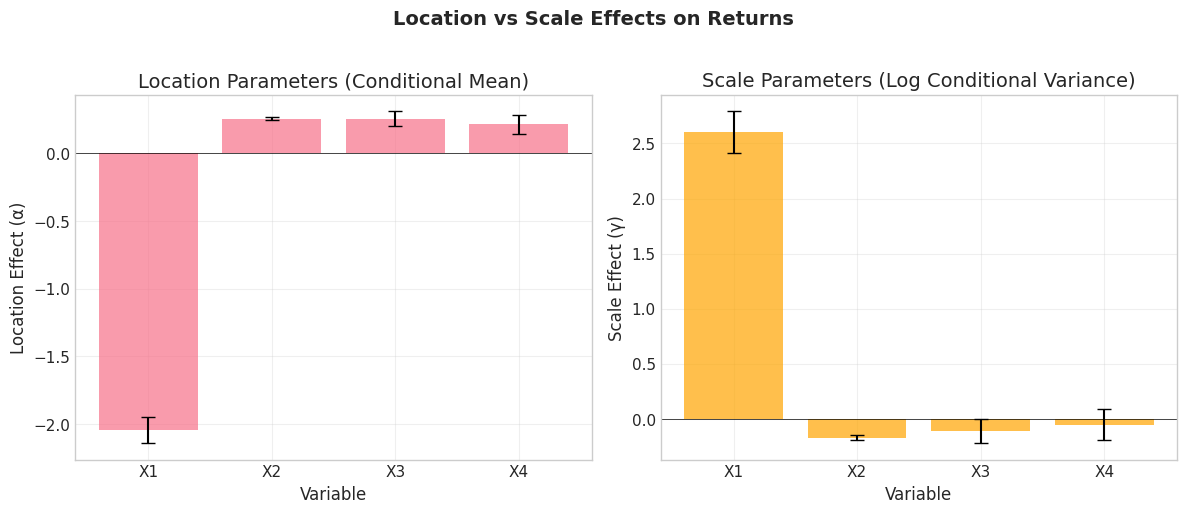

Left panel: How each variable affects expected returns (location)
Right panel: How each variable affects return dispersion (scale)


In [7]:
# Visualize location and scale effects
fig = ls_result.plot_location_scale_effects()
plt.suptitle("Location vs Scale Effects on Returns", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("Left panel: How each variable affects expected returns (location)")
print("Right panel: How each variable affects return dispersion (scale)")

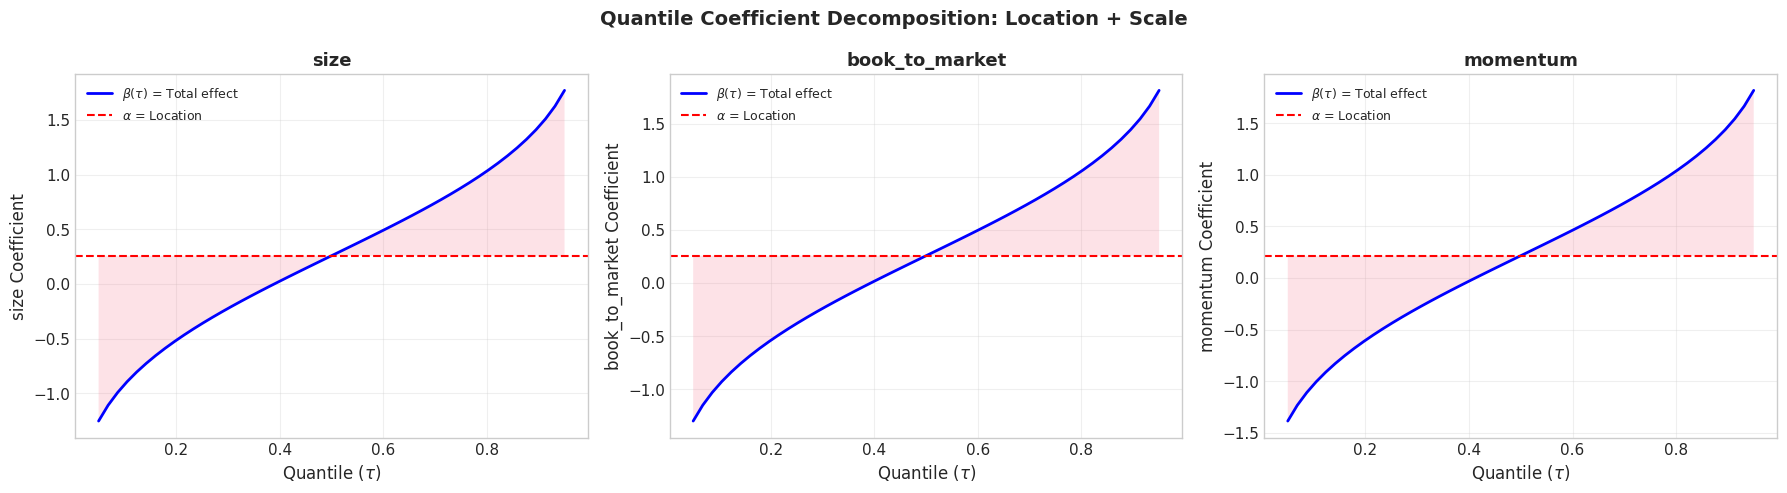

Each panel shows how the variable effect changes across quantiles.
The red dashed line is the location (mean) effect.
The blue shaded area shows the scale contribution.


In [8]:
# Decompose quantile effects for each variable
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

loc_names = ls_result.location_params_.index.tolist()
loc_vals = ls_result.location_params_.values
scale_vals = ls_result.scale_params_.values

plot_vars = loc_names[1:]  # Skip intercept
for var_idx, var_name in enumerate(plot_vars):
    ax = axes[var_idx]
    idx = var_idx + 1  # skip intercept in arrays

    alpha_i = loc_vals[idx]
    gamma_i = scale_vals[idx]
    sigma_i = np.exp(gamma_i / 2)

    tau_fine = np.linspace(0.05, 0.95, 50)
    beta_tau = [alpha_i + sigma_i * stats.norm.ppf(t) for t in tau_fine]

    ax.plot(tau_fine, beta_tau, "b-", linewidth=2, label=r"$\beta(\tau)$ = Total effect")
    ax.axhline(alpha_i, color="red", linestyle="--", linewidth=1.5, label=r"$\alpha$ = Location")
    ax.fill_between(tau_fine, alpha_i, beta_tau, alpha=0.2)
    ax.set_xlabel(r"Quantile ($\tau$)", fontsize=12)
    ax.set_ylabel(f"{var_name} Coefficient", fontsize=12)
    ax.set_title(f"{var_name}", fontsize=13, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Quantile Coefficient Decomposition: Location + Scale", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Each panel shows how the variable effect changes across quantiles.")
print("The red dashed line is the location (mean) effect.")
print("The blue shaded area shows the scale contribution.")

### 3.3 Comparison: Standard QR vs Location-Scale

Now we compare the quantile predictions and coefficients from both approaches. The key questions:
1. Do they agree on the coefficient paths?
2. Does the location-scale model prevent crossing?
3. Which model fits better?

No crossing detected for this observation in standard QR
Location-Scale predictions are monotonic BY CONSTRUCTION


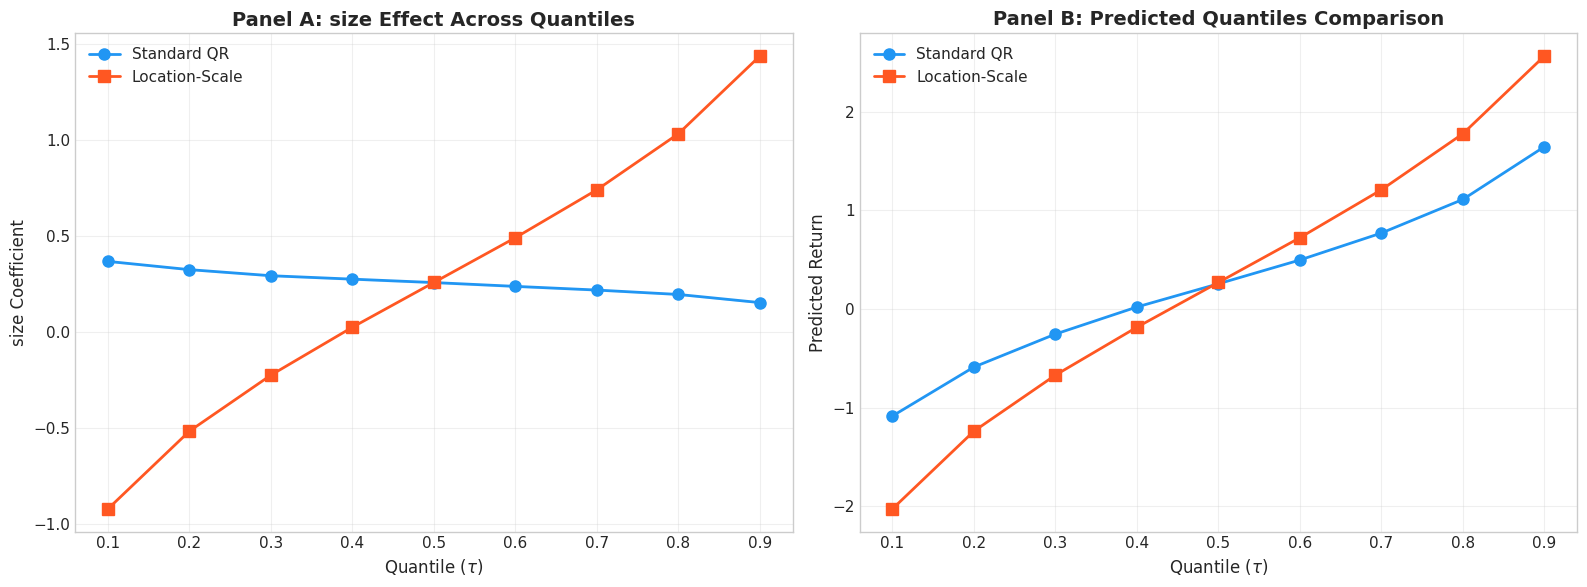


Plot saved to ../outputs/plots/05_qr_vs_location_scale.png


In [9]:
# Compare Standard QR with Location-Scale predictions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: Coefficient paths for 'size'
var_idx = 1  # size (index 1 in X which has const)
var_name = "size"

# Standard QR coefficients for 'size'
qr_coefs = []
qr_ses = []
for tau in tau_grid:
    params = qr_results[tau].params
    if params.ndim > 1:
        qr_coefs.append(params[var_idx, 0])
        se = qr_results[tau].std_errors
        qr_ses.append(se[var_idx, 0] if se.ndim > 1 else se[var_idx])
    else:
        qr_coefs.append(params[var_idx])
        qr_ses.append(qr_results[tau].std_errors[var_idx])

# Location-scale coefficients for 'size'
# Find 'size' index in location params
loc_vals = ls_result.location_params_.values
scale_vals = ls_result.scale_params_.values
alpha_size = loc_vals[var_idx]
gamma_size = scale_vals[var_idx]
sigma_size = np.exp(gamma_size / 2)
ls_coefs = [alpha_size + sigma_size * stats.norm.ppf(tau) for tau in tau_grid]

ax1.plot(tau_grid, qr_coefs, "o-", label="Standard QR", linewidth=2, markersize=8, color="#2196F3")
ax1.fill_between(
    tau_grid,
    [c - 1.96 * s for c, s in zip(qr_coefs, qr_ses)],
    [c + 1.96 * s for c, s in zip(qr_coefs, qr_ses)],
    alpha=0.15,
    color="#2196F3",
)
ax1.plot(
    tau_grid, ls_coefs, "s-", label="Location-Scale", linewidth=2, markersize=8, color="#FF5722"
)
ax1.set_xlabel(r"Quantile ($\tau$)", fontsize=12)
ax1.set_ylabel(f"{var_name} Coefficient", fontsize=12)
ax1.set_title(f"Panel A: {var_name} Effect Across Quantiles", fontsize=14, fontweight="bold")
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# Panel B: Predicted quantiles for a representative observation
X_test = X[0:1]  # First observation (with constant)

# Standard QR predictions
qr_preds = []
for tau in tau_grid:
    params = qr_results[tau].params
    if params.ndim > 1:
        qr_preds.append(float(X_test @ params[:, 0]))
    else:
        qr_preds.append(float(X_test @ params))

# Location-scale predictions (manual)
# ls_model.X is (n, 3) without constant, location_params_ has 4 values
# We use the model's internal X which is without constant
X_ls_test = ls_model.X[0:1]  # (1, 3)
location = float(np.dot(X_ls_test, loc_vals[1:]) + loc_vals[0])  # intercept + X*beta
log_scale = float(np.dot(X_ls_test, scale_vals[1:]) + scale_vals[0])  # intercept + X*gamma
scale = np.exp(log_scale / 2)
ls_preds = [location + scale * stats.norm.ppf(tau) for tau in tau_grid]

ax2.plot(tau_grid, qr_preds, "o-", label="Standard QR", linewidth=2, markersize=8, color="#2196F3")
ax2.plot(
    tau_grid, ls_preds, "s-", label="Location-Scale", linewidth=2, markersize=8, color="#FF5722"
)

# Check for crossing in standard QR
crossings = []
for i in range(len(tau_grid) - 1):
    if qr_preds[i] > qr_preds[i + 1]:
        crossings.append(i)

if crossings:
    for i in crossings:
        ax2.plot(
            [tau_grid[i], tau_grid[i + 1]],
            [qr_preds[i], qr_preds[i + 1]],
            "ro-",
            linewidth=3,
            zorder=5,
        )
    print(f"Standard QR has {len(crossings)} crossing(s) for this observation")
else:
    print("No crossing detected for this observation in standard QR")

print("Location-Scale predictions are monotonic BY CONSTRUCTION")

ax2.set_xlabel(r"Quantile ($\tau$)", fontsize=12)
ax2.set_ylabel("Predicted Return", fontsize=12)
ax2.set_title("Panel B: Predicted Quantiles Comparison", fontsize=14, fontweight="bold")
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "05_qr_vs_location_scale.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nPlot saved to {PLOTS_DIR / '05_qr_vs_location_scale.png'}")

---

## 4. Heteroskedasticity Testing

A key motivation for the location-scale model is explicit heteroskedasticity modeling. Here we test whether heteroskedasticity is present in our data, which would justify using location-scale over standard QR.

### 4.1 Visual Heteroskedasticity Check

We examine residuals from median regression to detect patterns of non-constant variance.

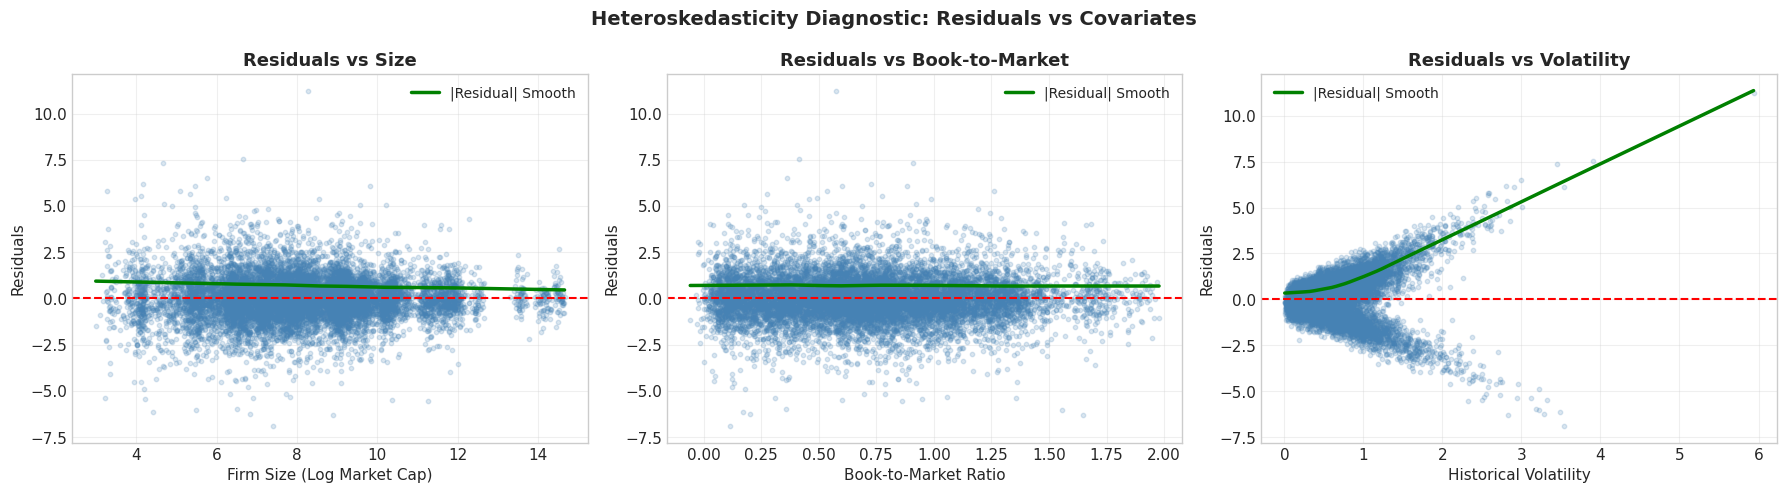

Plot saved to ../outputs/plots/05_heteroskedasticity_check.png

If the green LOWESS line slopes upward, residual dispersion increases with that variable
This indicates heteroskedasticity that the location-scale model can capture.


In [10]:
# Visual heteroskedasticity check
# Get residuals from median regression (standard QR at tau=0.5)
params_50 = qr_results[0.5].params
if params_50.ndim > 1:
    params_50 = params_50[:, 0]
fitted_50 = X @ params_50
resid_50 = y - fitted_50

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Residuals vs Size
axes[0].scatter(data["size"].values, resid_50, alpha=0.2, s=10, color="steelblue")
axes[0].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Firm Size (Log Market Cap)", fontsize=11)
axes[0].set_ylabel("Residuals", fontsize=11)
axes[0].set_title("Residuals vs Size", fontsize=13, fontweight="bold")
axes[0].grid(alpha=0.3)

# Add LOWESS smooth of |residuals|
try:
    from statsmodels.nonparametric.smoothers_lowess import lowess

    smooth = lowess(np.abs(resid_50), data["size"].values, frac=0.3)
    axes[0].plot(smooth[:, 0], smooth[:, 1], "g-", linewidth=2.5, label="|Residual| Smooth")
    axes[0].legend(fontsize=10)
except ImportError:
    print("statsmodels not available for LOWESS; skipping smooth")

# Panel 2: Residuals vs Book-to-Market
axes[1].scatter(data["book_to_market"].values, resid_50, alpha=0.2, s=10, color="steelblue")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Book-to-Market Ratio", fontsize=11)
axes[1].set_ylabel("Residuals", fontsize=11)
axes[1].set_title("Residuals vs Book-to-Market", fontsize=13, fontweight="bold")
axes[1].grid(alpha=0.3)

try:
    smooth2 = lowess(np.abs(resid_50), data["book_to_market"].values, frac=0.3)
    axes[1].plot(smooth2[:, 0], smooth2[:, 1], "g-", linewidth=2.5, label="|Residual| Smooth")
    axes[1].legend(fontsize=10)
except:
    pass

# Panel 3: Residuals vs Volatility
axes[2].scatter(data["volatility"].values, resid_50, alpha=0.2, s=10, color="steelblue")
axes[2].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[2].set_xlabel("Historical Volatility", fontsize=11)
axes[2].set_ylabel("Residuals", fontsize=11)
axes[2].set_title("Residuals vs Volatility", fontsize=13, fontweight="bold")
axes[2].grid(alpha=0.3)

try:
    smooth3 = lowess(np.abs(resid_50), data["volatility"].values, frac=0.3)
    axes[2].plot(smooth3[:, 0], smooth3[:, 1], "g-", linewidth=2.5, label="|Residual| Smooth")
    axes[2].legend(fontsize=10)
except:
    pass

plt.suptitle(
    "Heteroskedasticity Diagnostic: Residuals vs Covariates", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "05_heteroskedasticity_check.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Plot saved to {PLOTS_DIR / '05_heteroskedasticity_check.png'}")
print("\nIf the green LOWESS line slopes upward, residual dispersion increases with that variable")
print("This indicates heteroskedasticity that the location-scale model can capture.")

### 4.2 Formal Heteroskedasticity Test

We implement a simple Breusch-Pagan style test on the QR residuals: regress squared residuals on covariates and test if the coefficients are jointly significant.

**Hypotheses**:
- $H_0$: Homoskedasticity (scale function is constant)
- $H_1$: Heteroskedasticity (scale depends on covariates)

In [11]:
# Breusch-Pagan style heteroskedasticity test on QR residuals
print("Heteroskedasticity Test (Breusch-Pagan on QR Residuals)")
print("=" * 60)

# Squared residuals from median regression
resid_sq = resid_50**2

# Regress squared residuals on covariates
import statsmodels.api as sm

X_test_bp = sm.add_constant(data[["size", "book_to_market", "momentum", "volatility"]].values)
bp_model = sm.OLS(resid_sq, X_test_bp).fit()

# F-test for joint significance
f_stat = bp_model.fvalue
f_pval = bp_model.f_pvalue

print(f"F-statistic: {f_stat:.2f}")
print(f"p-value: {f_pval:.6f}")
print(f"R-squared of auxiliary regression: {bp_model.rsquared:.4f}")

# Also compute LM test statistic
n = len(resid_sq)
lm_stat = n * bp_model.rsquared
lm_pval = 1 - stats.chi2.cdf(lm_stat, df=X_test_bp.shape[1] - 1)

print(f"\nLM statistic: {lm_stat:.2f}")
print(f"LM p-value: {lm_pval:.6f}")

if f_pval < 0.05:
    print("\n-> REJECT homoskedasticity at 5% level")
    print("-> Location-Scale model is appropriate for this data")
else:
    print("\n-> FAIL TO REJECT homoskedasticity")
    print("-> Standard QR may be sufficient")

Heteroskedasticity Test (Breusch-Pagan on QR Residuals)


F-statistic: 3412.18
p-value: 0.000000
R-squared of auxiliary regression: 0.5322

LM statistic: 6386.93
LM p-value: 0.000000

-> REJECT homoskedasticity at 5% level
-> Location-Scale model is appropriate for this data


### 4.3 Distribution Assumption Test

The location-scale model assumes a reference distribution $F$ for the standardized errors. Let's test whether the normal assumption is reasonable.

Testing Normal Distribution Assumption
Note: Dot product shape mismatch, (4,) vs (3, 12000)
Computing manual normality test...

Kolmogorov-Smirnov: stat=0.1337, p=0.0000
Jarque-Bera: stat=4518.4853, p=0.0000
-> Evidence against normality. Consider logistic or t distribution.


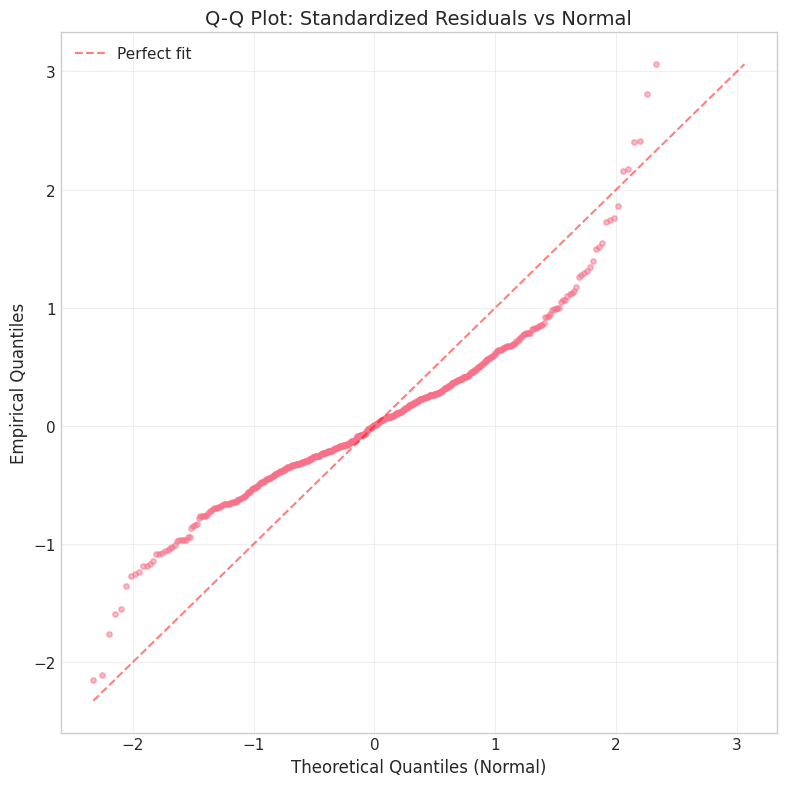

In [12]:
# Test normality assumption
print("Testing Normal Distribution Assumption")
print("=" * 60)

try:
    normality_result = ls_model.test_normality()
    normality_result.summary()

    # Q-Q plot
    fig = normality_result.plot_qq()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Note: {e}")
    print("Computing manual normality test...")

    # Manual computation with correct shapes
    loc_vals = ls_result.location_params_.values
    scale_vals = ls_result.scale_params_.values
    X_ls = ls_model.X  # (n, 3) without intercept

    location_fitted = loc_vals[0] + X_ls @ loc_vals[1:]  # intercept + X*alpha
    log_scale_fitted = scale_vals[0] + X_ls @ scale_vals[1:]  # intercept + X*gamma
    scale_fitted = np.exp(log_scale_fitted / 2)
    z_resids = (ls_model.y - location_fitted) / scale_fitted

    ks_stat, ks_pval = stats.kstest(z_resids, "norm")
    jb_stat, jb_pval = stats.jarque_bera(z_resids)

    print(f"\nKolmogorov-Smirnov: stat={ks_stat:.4f}, p={ks_pval:.4f}")
    print(f"Jarque-Bera: stat={jb_stat:.4f}, p={jb_pval:.4f}")

    if ks_pval < 0.05:
        print("-> Evidence against normality. Consider logistic or t distribution.")
    else:
        print("-> Normal distribution appears reasonable.")

    fig, ax = plt.subplots(figsize=(8, 8))
    theoretical = np.sort(stats.norm.ppf(np.linspace(0.01, 0.99, 500)))
    empirical = np.sort(np.random.choice(z_resids, 500, replace=False))
    ax.scatter(theoretical, empirical, alpha=0.5, s=15)
    lims = [min(theoretical.min(), empirical.min()), max(theoretical.max(), empirical.max())]
    ax.plot(lims, lims, "r--", alpha=0.5, label="Perfect fit")
    ax.set_xlabel("Theoretical Quantiles (Normal)")
    ax.set_ylabel("Empirical Quantiles")
    ax.set_title("Q-Q Plot: Standardized Residuals vs Normal")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

---

## 5. Case Study: Volatility Modeling

### Research Narrative

We now interpret the location-scale results in the context of financial risk modeling. The key insight is that firm characteristics affect **both expected returns AND volatility**.

### Interpretation Guide

```
INTERPRETING LOCATION-SCALE RESULTS:

LOCATION (alpha):
  alpha_size > 0: Larger firms have higher expected returns

SCALE (gamma):
  gamma_size < 0: Larger firms have exp(gamma/2) < 1 \u2192 LOWER volatility
  gamma_size > 0: Larger firms have exp(gamma/2) > 1 \u2192 HIGHER volatility

EFFECTIVE QUANTILE COEFFICIENT:
  beta_eff(tau) = alpha + exp(gamma/2) \u00b7 Phi^(-1)(tau)

  At tau=0.1 (bad times): Phi^(-1)(0.1) = -1.28
  At tau=0.9 (good times): Phi^(-1)(0.9) = +1.28
```

In [13]:
# Detailed interpretation of location-scale results
print("LOCATION-SCALE INTERPRETATION")
print("=" * 60)

loc_names = ls_result.location_params_.index.tolist()
loc_vals = ls_result.location_params_.values
scale_vals = ls_result.scale_params_.values

for i, name in enumerate(loc_names):
    if name == "Intercept":
        continue

    alpha = loc_vals[i]
    gamma = scale_vals[i]
    sigma = np.exp(gamma / 2)

    print(f"\n--- {name} ---")
    print(f"  Location effect (alpha):  {alpha:.4f}")
    print(f"  Scale effect (gamma):     {gamma:.4f}")
    print(f"  Scale multiplier exp(gamma/2): {sigma:.4f}")

    # Effective coefficients at key quantiles
    for tau_val, label in [(0.1, "Bad times"), (0.5, "Median"), (0.9, "Good times")]:
        q_tau = stats.norm.ppf(tau_val)
        beta_eff = alpha + sigma * q_tau
        print(f"  beta_eff(tau={tau_val:.1f}) [{label:>10}]: {beta_eff:.4f}")

    # Economic interpretation
    if gamma < 0:
        print(f"  -> {name} REDUCES dispersion (stabilizing effect)")
    elif gamma > 0:
        print(f"  -> {name} INCREASES dispersion (destabilizing effect)")
    else:
        print(f"  -> {name} has no effect on dispersion")

LOCATION-SCALE INTERPRETATION

--- size ---
  Location effect (alpha):  0.2575
  Scale effect (gamma):     -0.1682
  Scale multiplier exp(gamma/2): 0.9193
  beta_eff(tau=0.1) [ Bad times]: -0.9207
  beta_eff(tau=0.5) [    Median]: 0.2575
  beta_eff(tau=0.9) [Good times]: 1.4357
  -> size REDUCES dispersion (stabilizing effect)

--- book_to_market ---
  Location effect (alpha):  0.2565
  Scale effect (gamma):     -0.1107
  Scale multiplier exp(gamma/2): 0.9462
  beta_eff(tau=0.1) [ Bad times]: -0.9561
  beta_eff(tau=0.5) [    Median]: 0.2565
  beta_eff(tau=0.9) [Good times]: 1.4690
  -> book_to_market REDUCES dispersion (stabilizing effect)

--- momentum ---
  Location effect (alpha):  0.2159
  Scale effect (gamma):     -0.0519
  Scale multiplier exp(gamma/2): 0.9744
  beta_eff(tau=0.1) [ Bad times]: -1.0329
  beta_eff(tau=0.5) [    Median]: 0.2159
  beta_eff(tau=0.9) [Good times]: 1.4646
  -> momentum REDUCES dispersion (stabilizing effect)


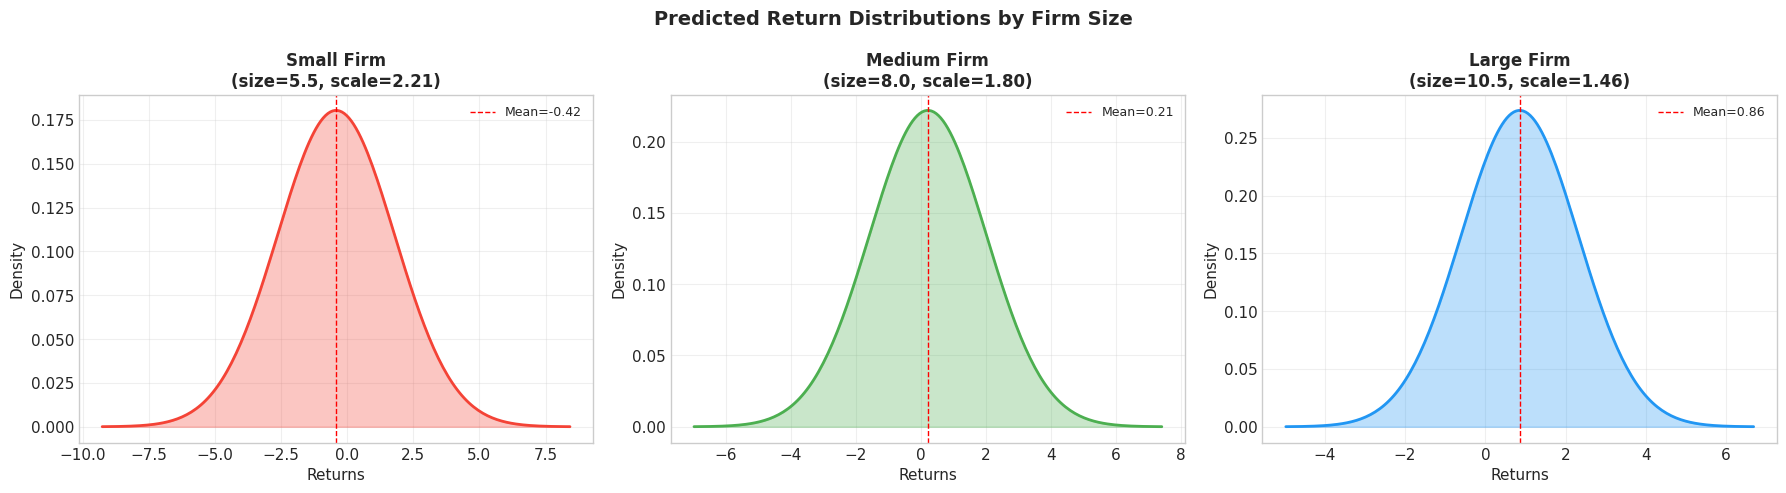

The width of each distribution reflects the scale (volatility) component.
Larger firms may have narrower distributions if gamma_size < 0.


In [14]:
# Compare predicted densities for different firm profiles
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

loc_vals = ls_result.location_params_.values
scale_vals = ls_result.scale_params_.values

# Define firm profiles (size is at index 1)
profiles = {
    "Small Firm": data["size"].quantile(0.1),
    "Medium Firm": data["size"].median(),
    "Large Firm": data["size"].quantile(0.9),
}

colors_profile = ["#F44336", "#4CAF50", "#2196F3"]

med_btm = data["book_to_market"].median()
med_mom = data["momentum"].median()

for ax_idx, (name, size_val) in enumerate(profiles.items()):
    x_vec = np.array([size_val, med_btm, med_mom])  # without intercept

    # Compute location and scale
    loc = loc_vals[0] + np.dot(x_vec, loc_vals[1:])  # intercept + X*alpha
    log_sc = scale_vals[0] + np.dot(x_vec, scale_vals[1:])  # intercept + X*gamma
    sc = np.exp(log_sc / 2)

    # Density grid
    y_grid = np.linspace(loc - 4 * sc, loc + 4 * sc, 200)
    density = stats.norm.pdf((y_grid - loc) / sc) / sc

    axes[ax_idx].fill_between(y_grid, density, alpha=0.3, color=colors_profile[ax_idx])
    axes[ax_idx].plot(y_grid, density, linewidth=2, color=colors_profile[ax_idx])
    axes[ax_idx].axvline(loc, color="red", linestyle="--", linewidth=1, label=f"Mean={loc:.2f}")
    axes[ax_idx].set_xlabel("Returns", fontsize=11)
    axes[ax_idx].set_ylabel("Density", fontsize=11)
    axes[ax_idx].set_title(
        f"{name}\n(size={size_val:.1f}, scale={sc:.2f})", fontsize=12, fontweight="bold"
    )
    axes[ax_idx].legend(fontsize=9)
    axes[ax_idx].grid(alpha=0.3)

plt.suptitle("Predicted Return Distributions by Firm Size", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("The width of each distribution reflects the scale (volatility) component.")
print("Larger firms may have narrower distributions if gamma_size < 0.")

### 5.1 Comparing Distributions

The location-scale model allows different reference distributions. Let's compare normal vs logistic to see how this choice affects the results.

In [15]:
# Compare different distribution assumptions
distributions = ["normal", "logistic", "t", "laplace"]
dist_results = {}

print("Comparing Distribution Assumptions")
print("=" * 60)

for dist in distributions:
    try:
        model = LocationScale(panel, formula=formula, tau=[0.1, 0.5, 0.9], distribution=dist)
        result = model.fit(verbose=False)
        dist_results[dist] = result

        print(f"\n{dist.upper()} Distribution:")
        print(f"  Location R-squared: {result.location_result.rsquared:.4f}")
        print(f"  Scale R-squared:    {result.scale_result.rsquared:.4f}")

        # Show coefficients at tau=0.5
        if 0.5 in result.results:
            params_05 = result.results[0.5].params
            print(f"  Median coefficients: {np.round(params_05, 4)}")
    except Exception as e:
        print(f"  {dist}: Error - {e}")

# Compare implied quantile coefficients
if len(dist_results) > 1:
    print("\n\nComparison at tau=0.1 (left tail):")
    print(f"{'Distribution':<12}", end="")
    for var in var_names:
        print(f"{var:>15}", end="")
    print()
    print("-" * (12 + 15 * len(var_names)))

    for dist, result in dist_results.items():
        if 0.1 in result.results:
            print(f"{dist:<12}", end="")
            for coef in result.results[0.1].params:
                print(f"{coef:15.4f}", end="")
            print()

Comparing Distribution Assumptions

NORMAL Distribution:
  Location R-squared: 0.1663
  Scale R-squared:    0.0205
  Median coefficients: Intercept        -2.0442
X0                   NaN
X1                   NaN
X2                   NaN
book_to_market       NaN
momentum             NaN
size                 NaN
dtype: float64

LOGISTIC Distribution:
  Location R-squared: 0.1663
  Scale R-squared:    0.0205
  Median coefficients: Intercept        -2.0442
X0                   NaN
X1                   NaN
X2                   NaN
book_to_market       NaN
momentum             NaN
size                 NaN
dtype: float64

T Distribution:
  Location R-squared: 0.1663
  Scale R-squared:    0.0205
  Median coefficients: Intercept        -2.0442
X0                   NaN
X1                   NaN
X2                   NaN
book_to_market       NaN
momentum             NaN
size                 NaN
dtype: float64

LAPLACE Distribution:
  Location R-squared: 0.1663
  Scale R-squared:    0.0205
  Median

---

## 6. When to Use Location-Scale

### Decision Guide

| Criterion | Use Location-Scale | Use Standard QR |
|-----------|-------------------|------------------|
| **Heteroskedasticity** | Detected (BP/He-Zhu test rejects) | Not detected |
| **Crossing** | Observed in standard QR | Not observed |
| **Interest** | Both central tendency AND dispersion | Only conditional quantiles |
| **Theory** | Suggests explicit risk/volatility model | No structural assumption needed |
| **Monotonicity** | Required by construction | Acceptable to check post-hoc |
| **Flexibility** | Willing to impose distributional structure | Want fully flexible coefficients |
| **Efficiency** | Want to gain from structure | Prefer robustness over efficiency |

### Summary Comparison

```
Location-Scale ADVANTAGES:
  + Monotonicity guaranteed (no crossing)
  + Explicit heteroskedasticity model
  + Efficient (fewer parameters)
  + Clean interpretation (location vs scale)
  + Density prediction

Location-Scale DISADVANTAGES:
  - Distributional assumption (F)
  - Less flexible than standard QR
  - Misspecified F \u2192 biased quantile coefficients
  - Requires sufficient heteroskedasticity to be useful
```

In [16]:
# Save location and scale parameters to CSV
results_rows = []

loc_names = ls_result.location_params_.index.tolist()
loc_vals = ls_result.location_params_.values
scale_vals = ls_result.scale_params_.values
cov_loc = np.asarray(ls_result.location_result.cov_params)
cov_scale = np.asarray(ls_result.scale_result.cov_params)

for i, name in enumerate(loc_names):
    alpha = loc_vals[i]
    gamma = scale_vals[i]
    sigma = np.exp(gamma / 2)

    row = {
        "variable": name,
        "location_alpha": alpha,
        "scale_gamma": gamma,
        "scale_multiplier": sigma,
        "location_se": np.sqrt(cov_loc[i, i]),
        "scale_se": np.sqrt(cov_scale[i, i] * 4),
    }

    # Add effective coefficients at key quantiles
    for tau_val in [0.1, 0.25, 0.5, 0.75, 0.9]:
        row[f"beta_eff_tau{int(tau_val * 100)}"] = alpha + sigma * stats.norm.ppf(tau_val)

    results_rows.append(row)

results_df = pd.DataFrame(results_rows)
results_df.to_csv(RESULTS_DIR / "05_location_scale_params.csv", index=False)

print("Results saved to outputs/results/05_location_scale_params.csv")
display(results_df)

Results saved to outputs/results/05_location_scale_params.csv


,variable,location_alpha,scale_gamma,scale_multiplier,location_se,scale_se,beta_eff_tau10,beta_eff_tau25,beta_eff_tau50,beta_eff_tau75,beta_eff_tau90
0,Intercept,-2.0442,2.6003,3.6699,0.0490,0.0972,-6.7474,-4.5195,-2.0442,0.4311,2.6590
1,size,0.2575,-0.1682,0.9193,0.0054,0.0107,-0.9207,-0.3626,0.2575,0.8776,1.4357
2,book_to_market,0.2565,-0.1107,0.9462,0.0275,0.0546,-0.9561,-0.3817,0.2565,0.8947,1.4690
3,momentum,0.2159,-0.0519,0.9744,0.0357,0.0707,-1.0329,-0.4413,0.2159,0.8731,1.4646


---

## 7. Exercises

### Exercise 1: Why Exponential Scale? (Easy)

**Question**: Why does the location-scale model use $\sigma(X) = \exp(X'\gamma/2)$ instead of $\sigma(X) = X'\gamma$ for the scale function?

Consider:
1. What constraint must the scale function satisfy?
2. What happens if $X'\gamma < 0$ with a linear scale function?
3. How does the exponential link guarantee this constraint?

**Write your answer as comments in the cell below.**

In [17]:
# Exercise 1: Why exponential scale function?

# TODO: Explain in comments:
# 1. The scale function must be strictly positive (sigma > 0)
# 2. If sigma(X) = X'gamma, negative values are possible when X'gamma < 0
# 3. exp(X'gamma/2) is always positive regardless of X'gamma values
# 4. This is analogous to the log-link in GLMs (Poisson, Gamma)

### Exercise 2: Manual Location-Scale (Easy)

**Task**: Implement the two-step location-scale estimation manually:
1. Step 1: Estimate $\hat{\alpha}$ from median regression (or OLS)
2. Step 2: Regress $\log|e_i|$ on $X$ to get $\hat{\gamma}$
3. Compute effective coefficients $\hat{\beta}(\tau) = \hat{\alpha} + \exp(\hat{\gamma}/2) \cdot \Phi^{-1}(\tau)$

Compare your manual results with PanelBox's `LocationScale` output.

In [18]:
# Exercise 2: Manual location-scale estimation

# TODO: Step 1 - Estimate location using OLS
# beta_ols = np.linalg.lstsq(X, y, rcond=None)[0]
# resid_ols = y - X @ beta_ols

# TODO: Step 2 - Estimate scale from log absolute residuals
# log_abs_resid = np.log(np.maximum(np.abs(resid_ols), 1e-10))
# gamma_hat = np.linalg.lstsq(X, log_abs_resid, rcond=None)[0]

# TODO: Step 3 - Compute effective coefficients
# For tau in [0.1, 0.5, 0.9]:
#   beta_eff = beta_ols + np.exp(gamma_hat/2) * stats.norm.ppf(tau)

# TODO: Compare with PanelBox results

### Exercise 3: Normal vs Logistic Distribution (Medium)

**Task**: Compare location-scale models with normal and logistic distributions:
1. Fit both models using `distribution='normal'` and `distribution='logistic'`
2. Compare the implied quantile coefficients at $\tau \in \{0.1, 0.25, 0.5, 0.75, 0.9\}$
3. Plot the coefficient paths for a variable of your choice
4. Which distribution provides a better fit? Use the normality test to decide.

In [19]:
# Exercise 3: Normal vs Logistic comparison

# TODO: Fit location-scale with normal distribution
# TODO: Fit location-scale with logistic distribution
# TODO: Compare coefficients across distributions
# TODO: Plot coefficient paths
# TODO: Use test_normality() to assess distributional fit

### Exercise 4: Effective Coefficient Derivation (Medium)

**Task**: Derive and verify the effective coefficient formula:

$$\beta_{\text{eff}}(\tau) = \alpha + \exp(\gamma/2) \cdot F^{-1}(\tau)$$

Steps:
1. Start from $Y = X'\alpha + \exp(X'\gamma/2) \cdot \varepsilon$
2. Show that $Q_\tau(Y|X) = X' \left[\alpha + \exp(\gamma/2) \cdot F^{-1}(\tau)\right]$
3. Verify numerically: compute $\beta_{\text{eff}}(\tau)$ for several $\tau$ values
4. Show that $\beta_{\text{eff}}(0.5) = \alpha$ when $F$ is symmetric

In [20]:
# Exercise 4: Verify effective coefficient formula

# TODO: Compute beta_eff(tau) = alpha + exp(gamma/2) * F^{-1}(tau)
# for tau in np.linspace(0.05, 0.95, 19)

# TODO: Show that for symmetric F (normal, logistic):
# beta_eff(0.5) = alpha (since F^{-1}(0.5) = 0)

# TODO: Plot beta_eff(tau) vs tau for each variable

### Exercise 5: Simulation with Known Heteroskedasticity (Hard)

**Task**: Simulate panel data with a known location-scale structure and show that:
1. The location-scale model recovers the true parameters
2. Standard QR gives noisy estimates that may cross

**DGP**:
```
y_it = 1.0 + 0.5*x1_it + 0.3*x2_it + exp(0.2 + 0.4*x1_it) * epsilon_it
where epsilon_it ~ N(0,1)
```

True location: alpha = [1.0, 0.5, 0.3]
True scale: gamma = [0.4, 0.8, 0.0] (note: gamma = 2 * [0.2, 0.4, 0.0])

In [21]:
# Exercise 5: Simulation study

# TODO: Generate simulated panel data
# N=100 entities, T=20 periods
# DGP: y_it = 1.0 + 0.5*x1 + 0.3*x2 + exp(0.2 + 0.4*x1) * eps
# where eps ~ N(0,1)

# TODO: Estimate location-scale model
# TODO: Estimate standard QR at multiple quantiles
# TODO: Compare estimated vs true parameters
# TODO: Check for crossing in standard QR predictions

### Exercise 6: Wage Distribution Analysis (Hard)

**Task**: Apply the location-scale model to wage data to decompose:
- **Location**: How education, experience, etc. affect expected wages
- **Scale**: How these factors affect wage dispersion (inequality)

Use the simulated heteroskedastic dataset (`../data/simulated/heteroskedastic.csv`) and:
1. Fit a location-scale model
2. Interpret which variables affect location vs scale differently
3. Create a visualization showing predicted wage distributions for different education levels

In [22]:
# Exercise 6: Wage distribution application

# TODO: Load heteroskedastic data
# data_het = pd.read_csv(DATA_DIR / 'simulated' / 'heteroskedastic.csv')

# TODO: Create PanelData object
# TODO: Fit LocationScale model
# TODO: Interpret location vs scale effects
# TODO: Plot predicted distributions

---

## 8. Summary and Key Takeaways

1. **Location-scale decomposition**: The MSS (2019) model separates how covariates affect the central tendency ($\alpha$) from how they affect dispersion ($\gamma$) of the outcome.

2. **Monotonicity by construction**: Unlike standard QR, location-scale quantile predictions cannot cross because $Q_\tau = \mu + \sigma \cdot F^{-1}(\tau)$ is monotonically increasing in $\tau$.

3. **Heteroskedasticity modeling**: The scale function $\sigma(X) = \exp(X'\gamma/2)$ explicitly models how variance depends on covariates, complementing the heteroskedasticity test.

4. **Interpretation**: $\alpha$ captures "mean effects" while $\gamma$ captures "risk/volatility effects." A variable with $\alpha > 0, \gamma < 0$ increases expected returns while reducing risk.

5. **Distribution choice**: The reference distribution $F$ (normal, logistic, t, laplace) affects tail behavior. Use normality tests and Q-Q plots to assess the assumption.

6. **Trade-off**: Location-scale gains efficiency by imposing structure but loses flexibility compared to standard QR. Use it when heteroskedasticity is present and the distributional assumption is reasonable.

### References

1. **Machado, J. A., & Santos Silva, J. M. C. (2019)**. "Quantiles via Moments". *Journal of Econometrics*, 213(1), 145-173.
2. **Koenker, R., & Xiao, Z. (2002)**. "Inference on the Quantile Regression Process". *Econometrica*, 70(4), 1583-1612.
3. **He, X., & Zhu, L. (2003)**. "A Lack-of-Fit Test for Quantile Regression". *JASA*, 98(464), 1013-1022.
4. **Frumento, P., & Bottai, M. (2016)**. "Parametric Modeling of Quantile Regression Coefficient Functions". *Biometrics*, 72(1), 74-84.

### Next Steps

In **Notebook 06**, we will explore **Dynamic Quantile Regression**, which introduces lagged dependent variables into the quantile regression framework.